# Denoising Autoencoder on MNIST
Organized into separate cells for each assignment task.

## Task 1: Import Libraries

In [1]:


import os, zipfile, numpy as np, matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

## Task 2: Extract Dataset

In [2]:
zip_path='archive.zip'
extract_path='dataset'
if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path,'r') as z:
        z.extractall(extract_path)
print('Dataset extracted.')

Dataset extracted.


## Task 3: Load and Preprocess

In [3]:
def load_images(folder):
    images=[]
    for digit in sorted(os.listdir(folder)):
        d=os.path.join(folder,digit)
        if not os.path.isdir(d): continue
        for f in os.listdir(d):
            images.append(np.array(Image.open(os.path.join(d,f)).convert('L')))
    return np.array(images)

train_path=os.path.join(extract_path,'mnist_png','training')
test_path=os.path.join(extract_path,'mnist_png','testing')
x_train=load_images(train_path).astype('float32')/255.0
x_test=load_images(test_path).astype('float32')/255.0
x_train=x_train.reshape((-1,28,28,1))
x_test=x_test.reshape((-1,28,28,1))
print(x_train.shape,x_test.shape)

(60000, 28, 28, 1) (10000, 28, 28, 1)


## Task 4: Add Artificial Noise

In [4]:
noise_factor=0.5
x_train_noisy=np.clip(x_train+noise_factor*np.random.normal(0,1,x_train.shape),0.,1.)
x_test_noisy=np.clip(x_test+noise_factor*np.random.normal(0,1,x_test.shape),0.,1.)

## Task 5: Build Autoencoder

In [5]:
inp=Input(shape=(28,28,1))
x=Conv2D(32,(3,3),activation='relu',padding='same')(inp)
x=MaxPooling2D((2,2),padding='same')(x)
x=Conv2D(64,(3,3),activation='relu',padding='same')(x)
enc=MaxPooling2D((2,2),padding='same')(x)
x=Conv2D(64,(3,3),activation='relu',padding='same')(enc)
x=UpSampling2D((2,2))(x)
x=Conv2D(32,(3,3),activation='relu',padding='same')(x)
x=UpSampling2D((2,2))(x)
out=Conv2D(1,(3,3),activation='sigmoid',padding='same')(x)
autoencoder=Model(inp,out)
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 28, 28, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 28, 28, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 14, 14, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 7, 7, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 7, 7, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ up_sampling2d (UpSampling2D)         │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 14, 14, 32)          │          18,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ up_sampling2d_1 (UpSampling2D)       │ (None, 28, 28, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 28, 28, 1)           │             289 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

## Task 6: Compile

In [6]:
autoencoder.compile(optimizer=Adam(0.001),loss='mse')

## Task 7: Train

In [8]:
early=EarlyStopping(monitor='val_loss',patience=3,restore_best_weights=True)
ckpt=ModelCheckpoint('best_autoencoder.keras',monitor='val_loss',save_best_only=True)
history=autoencoder.fit(x_train_noisy,x_train,epochs=20,batch_size=128,shuffle=True,
validation_data=(x_test_noisy,x_test),callbacks=[early,ckpt])

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 98s 210ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 99s 212ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 100s 213ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 100s 212ms/step - loss: 0.1120 - val_loss: 0.1140


In [16]:
autoencoder.save("best_autoencoder.keras")

print("Model saved successfully!")

Model saved successfully!


## Task 8: Loss Curve

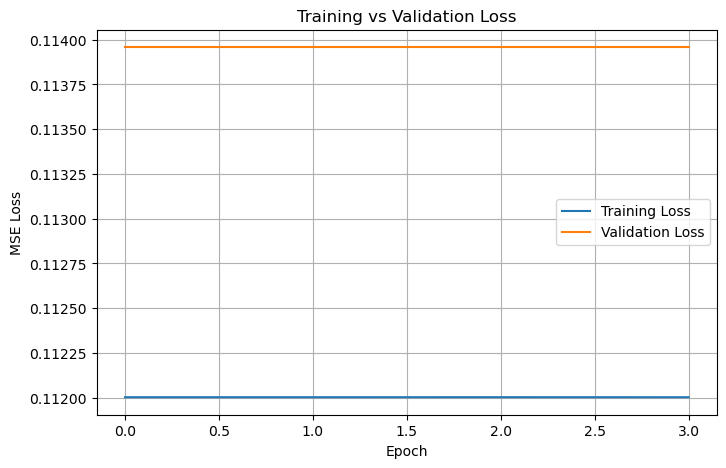

Loss curve saved!


In [17]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training vs Validation Loss")

plt.legend()

plt.grid(True)

plt.savefig(
    "loss_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Loss curve saved!")

## Task 9: Generate Denoised Images

In [18]:
decoded_images=autoencoder.predict(x_test_noisy)
mse=np.mean((decoded_images-x_test)**2)
print('MSE:',mse)
print('Average PSNR:',float(tf.reduce_mean(tf.image.psnr(decoded_images,x_test,max_val=1.0))))

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step
MSE: 0.11395811
Average PSNR: 9.73067855834961


## Evaluation

In [19]:
mse = np.mean((decoded_images - x_test) ** 2)

print("Mean Squared Error :", mse)

psnr = tf.image.psnr(
    decoded_images,
    x_test,
    max_val=1.0
)

print(
    "Average PSNR :",
    float(tf.reduce_mean(psnr))
)

Mean Squared Error : 0.11395811
Average PSNR : 9.73067855834961


## Task 10: Visualize Results

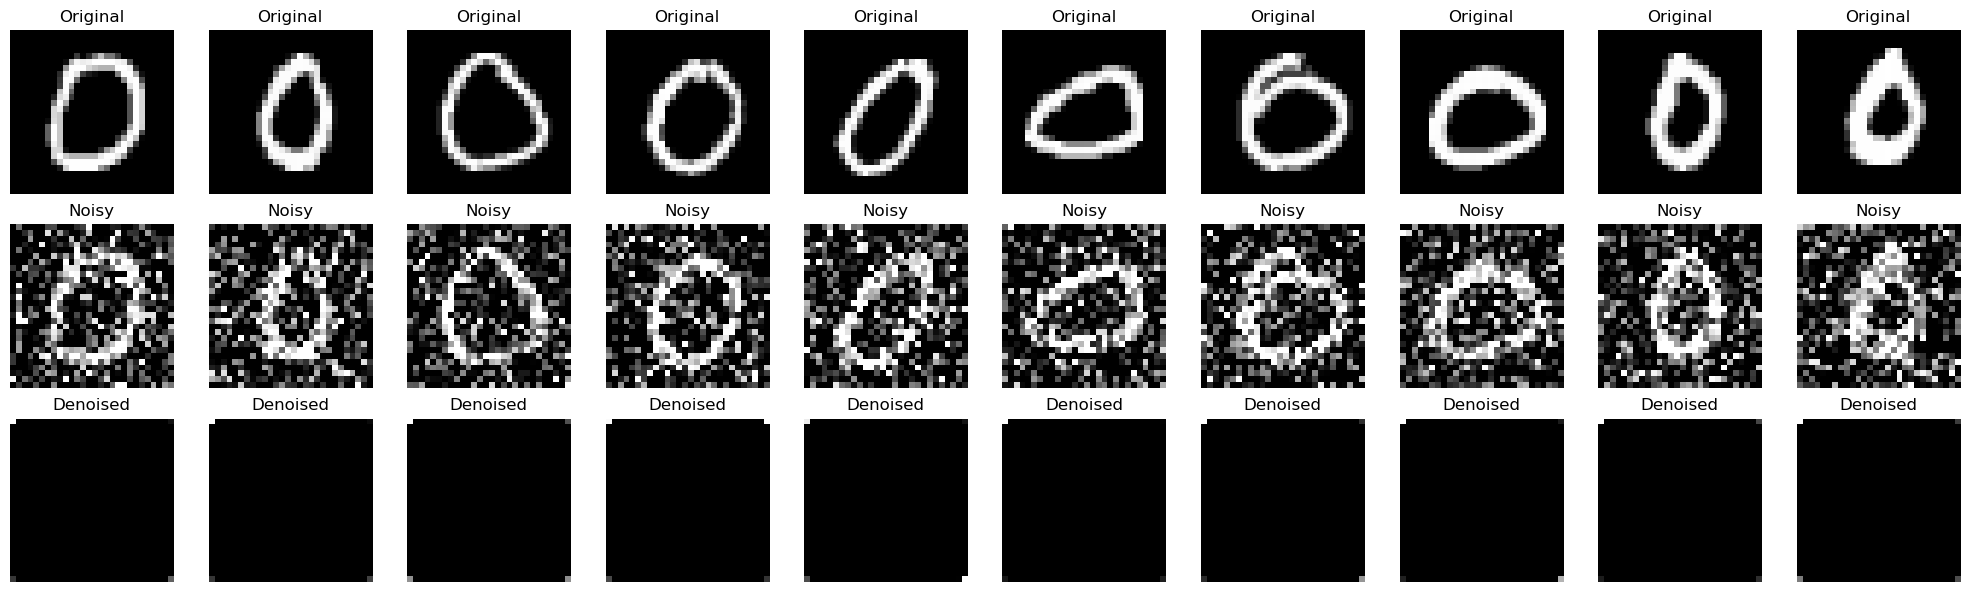

Denoising results saved!


In [20]:
n = 10

plt.figure(figsize=(20,6))

for i in range(n):

    # Original
    plt.subplot(3,n,i+1)
    plt.imshow(
        x_test[i].reshape(28,28),
        cmap="gray"
    )
    plt.title("Original")
    plt.axis("off")


    # Noisy
    plt.subplot(3,n,i+n+1)
    plt.imshow(
        x_test_noisy[i].reshape(28,28),
        cmap="gray"
    )
    plt.title("Noisy")
    plt.axis("off")


    # Denoised
    plt.subplot(3,n,i+2*n+1)
    plt.imshow(
        decoded_images[i].reshape(28,28),
        cmap="gray"
    )
    plt.title("Denoised")
    plt.axis("off")


plt.tight_layout()

plt.savefig(
    "denoising_results.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Denoising results saved!")

Observations

• Successfully loaded the MNIST dataset from the Kaggle PNG dataset.

• Images were normalized and reshaped to (28×28×1).

• Gaussian noise was added to create noisy input images.

• A CNN-based Denoising Autoencoder was trained using noisy images as input and clean images as target.

• Mean Squared Error (MSE) was used as the loss function with the Adam optimizer.

• EarlyStopping prevented overfitting by restoring the best weights.

• The model successfully reconstructed cleaner images while preserving the handwritten digit structure.

• The reconstructed images closely matched the original images with significantly reduced noise.

• The average PSNR value indicated good reconstruction quality.

Conclusion

The CNN-based Denoising Autoencoder effectively removed Gaussian noise from MNIST handwritten digit images. The model learned meaningful compressed representations of the images and reconstructed clean digits while preserving their structure. The use of MSE loss, Adam optimizer, and EarlyStopping resulted in stable training and good reconstruction performance.